# AGORA Multiplex Graph Exploration
Interactive sandbox for loading and experimenting with community detection algorithms.

In [58]:
import json
import csv
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import numpy as np
from pathlib import Path
from collections import Counter
from typing import Union

ROOT = Path('../')
AGENTS_OUT = ROOT / 'pipeline/agents/output'
MULTIPLEX_DIR = ROOT / 'pipeline/multiplex_graph'
DATA_CSV = ROOT / 'knowledge_graph/data/agora_with_sponsors.csv'

print('Paths ready')

Paths ready


## 1. Load Data

In [59]:
# Load sponsor graph (Layer 1)
G_sponsor = nx.read_graphml(MULTIPLEX_DIR / 'layer_1_sponsor.graphml')

print(f'Layer 1 — Sponsor Graph')
print(f'  Nodes: {G_sponsor.number_of_nodes()}')
print(f'  Edges: {G_sponsor.number_of_edges()}')

node_type_counts = Counter(d.get('node_type','?') for _,d in G_sponsor.nodes(data=True))
edge_type_counts = Counter(d.get('relation','?') for _,_,d in G_sponsor.edges(data=True))
print(f'  Node types: {dict(node_type_counts)}')
print(f'  Edge types: {dict(edge_type_counts)}')

Layer 1 — Sponsor Graph
  Nodes: 710
  Edges: 2387
  Node types: {'Sponsor': 201, 'Document': 509}
  Edge types: {'SPONSORED_BY': 509, 'SHARES_SPONSOR': 1878}


In [60]:
# Load communities
with open(AGENTS_OUT / 'communities.json') as f:
    communities = json.load(f)

# Build doc -> community mapping
doc_to_community = {}
for c in communities:
    for aid in c['member_agora_ids']:
        doc_to_community[aid] = c['community_id']

sizes = sorted([len(c['member_agora_ids']) for c in communities], reverse=True)
print(f'Communities: {len(communities)}')
print(f'Top-10 sizes: {sizes[:10]}')
print(f'Singletons: {sum(1 for s in sizes if s == 1)}')
print(f'Mid-size (2-10): {sum(1 for s in sizes if 2 <= s <= 10)}')
print(f'Large (>10): {sum(1 for s in sizes if s > 10)}')

Communities: 243
Top-10 sizes: [139, 32, 29, 26, 18, 9, 4, 4, 4, 3]
Singletons: 204
Mid-size (2-10): 34
Large (>10): 5


In [61]:
# Load document metadata
doc_meta = {}
with open(DATA_CSV) as f:
    reader = csv.DictReader(f)
    for row in reader:
        aid = row.get('AGORA ID', '').strip()
        if aid:
            doc_meta[aid] = {
                'name': row.get('Official name', ''),
                'summary': row.get('Short summary', ''),
                'sponsor': row.get('Sponsor_Name', ''),
                'party': row.get('Sponsor_Party', ''),
                'state': row.get('Sponsor_State', ''),
                'bioguide': row.get('Sponsor_bioguideId', ''),
            }

print(f'Loaded metadata for {len(doc_meta)} documents')

Loaded metadata for 535 documents


## 2. Build Document-Only Similarity Graph
Extract the SHARES_SPONSOR subgraph (document nodes only) for community algorithm experiments.

In [62]:
# Extract document-only SHARES_SPONSOR graph
doc_nodes = [n for n, d in G_sponsor.nodes(data=True) if d.get('node_type') == 'Document']
G_docs = G_sponsor.subgraph(doc_nodes).copy()

# Keep only SHARES_SPONSOR edges
edges_to_remove = [(u, v) for u, v, d in G_docs.edges(data=True) if d.get('relation') != 'SHARES_SPONSOR']
G_docs.remove_edges_from(edges_to_remove)

print(f'Document similarity graph: {G_docs.number_of_nodes()} nodes, {G_docs.number_of_edges()} edges')

# Annotate with existing community labels and metadata
for node in G_docs.nodes():
    G_docs.nodes[node]['community'] = doc_to_community.get(node, 'singleton')
    meta = doc_meta.get(node, {})
    G_docs.nodes[node]['party'] = meta.get('party', '')
    G_docs.nodes[node]['sponsor'] = meta.get('sponsor', '')
    G_docs.nodes[node]['name'] = meta.get('name', '')[:60]

Document similarity graph: 509 nodes, 1878 edges


## 3. Community Size Distribution

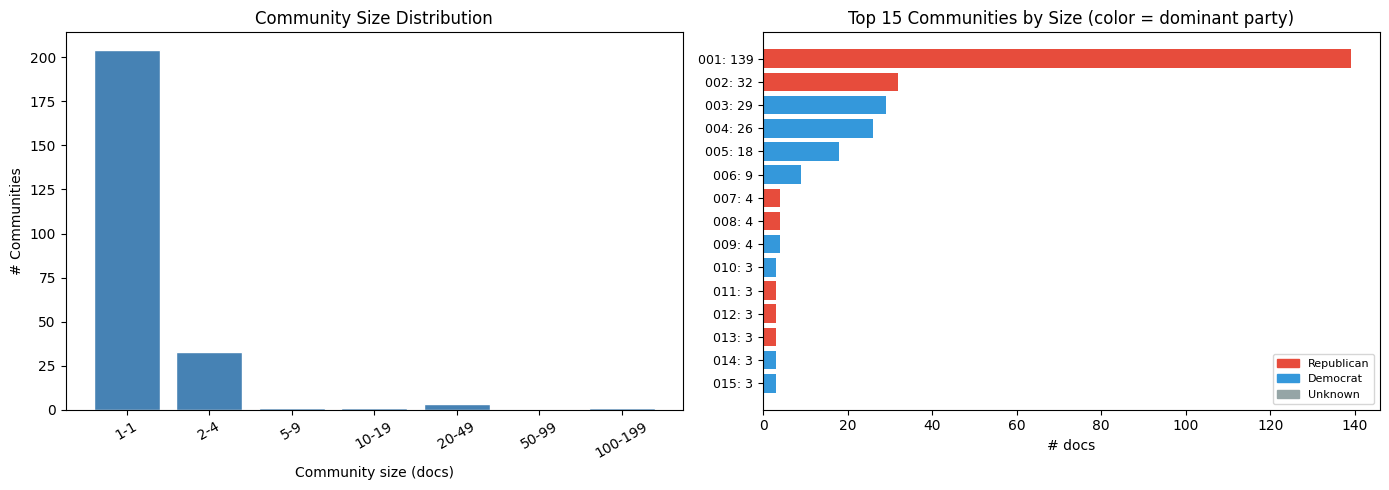

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Size histogram
ax = axes[0]
size_bins = [1, 2, 5, 10, 20, 50, 100, 200]
size_counts = [sum(1 for s in sizes if lo <= s < hi) for lo, hi in zip(size_bins, size_bins[1:])]
size_labels = [f'{lo}-{hi-1}' for lo, hi in zip(size_bins, size_bins[1:])]
ax.bar(range(len(size_counts)), size_counts, color='steelblue', edgecolor='white')
ax.set_xticks(range(len(size_counts)))
ax.set_xticklabels(size_labels, rotation=30)
ax.set_title('Community Size Distribution')
ax.set_xlabel('Community size (docs)')
ax.set_ylabel('# Communities')

# Top communities by size
ax2 = axes[1]
top_comms = sorted(communities, key=lambda c: -len(c['member_agora_ids']))[:15]
labels = [f"{c['community_id'].split(':')[1]}: {len(c['member_agora_ids'])}" for c in top_comms]
vals = [len(c['member_agora_ids']) for c in top_comms]
party_cmap = {'R': '#e74c3c', 'D': '#3498db', '': '#95a5a6'}
colors_bar = [party_cmap.get(c.get('dominant_party', ''), '#95a5a6') for c in top_comms]
ax2.barh(range(len(top_comms)), vals[::-1], color=colors_bar[::-1])
ax2.set_yticks(range(len(top_comms)))
ax2.set_yticklabels(labels[::-1], fontsize=9)
ax2.set_title('Top 15 Communities by Size (color = dominant party)')
ax2.set_xlabel('# docs')
for h in [mpatches.Patch(color='#e74c3c', label='R'), mpatches.Patch(color='#3498db', label='D'), mpatches.Patch(color='#95a5a6', label='?')]:
    pass
ax2.legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Republican'),
    mpatches.Patch(color='#3498db', label='Democrat'),
    mpatches.Patch(color='#95a5a6', label='Unknown'),
], loc='lower right', fontsize=8)

plt.tight_layout()
plt.show()

## 4. Community Inspector
Examine any community by ID.

In [64]:
def inspect_community(community_id: Union[str, int]):
    """Print details about a community. Pass int (1-based) or full id like 'community:001'."""
    if isinstance(community_id, int):
        community_id = f'community:{community_id:03d}'
    c = next((c for c in communities if c['community_id'] == community_id), None)
    if not c:
        print(f'Not found: {community_id}')
        return
    
    print(f'=== {c["community_id"]} ({len(c["member_agora_ids"])} docs) ===')
    print(f'Label: {c["label"]}')
    print(f'Dominant party: {c["dominant_party"]}')
    print(f'Taxonomy signature: {c["taxonomy_signature"]}')
    print(f'Bill groups: {len(c["bill_groups"])} groups')
    
    centrality = c.get('doc_centrality', {})
    top_docs = sorted(c['member_agora_ids'], key=lambda x: -centrality.get(x, 0))[:10]
    
    print(f'\nTop 10 docs by centrality:')
    for aid in top_docs:
        meta = doc_meta.get(aid, {})
        cent = centrality.get(aid, 0)
        party = meta.get('party', '?')
        sponsor = meta.get('sponsor', '')[:30]
        name = meta.get('name', '')[:60]
        print(f'  [{party}] {aid} (cent={cent:.3f}) — {sponsor}: {name}')

# Example
inspect_community(1)

=== community:001 (139 docs) ===
Label: Applications: Government: military and public safety | Strategies: Government study or report | Strategies: Government support
Dominant party: R
Taxonomy signature: ['Applications: Government: military and public safety', 'Strategies: Government study or report', 'Strategies: Government support', 'Strategies: Evaluation']
Bill groups: 8 groups

Top 10 docs by centrality:
  [D] 10 (cent=0.315) — Rep. DeFazio, Peter A. [D-OR-4: James M. Inhofe National Defense Authorization Act for Fisca
  [D] 11 (cent=0.315) — Rep. DeFazio, Peter A. [D-OR-4: James M. Inhofe National Defense Authorization Act for Fisca
  [D] 1161 (cent=0.315) — Rep. DeFazio, Peter A. [D-OR-4: James M. Inhofe National Defense Authorization Act for Fisca
  [D] 12 (cent=0.315) — Rep. DeFazio, Peter A. [D-OR-4: James M. Inhofe National Defense Authorization Act for Fisca
  [D] 13 (cent=0.315) — Rep. DeFazio, Peter A. [D-OR-4: James M. Inhofe National Defense Authorization Act for Fisca

In [ ]:
inspect_community(2)

## 5. Visualize a Community Graph

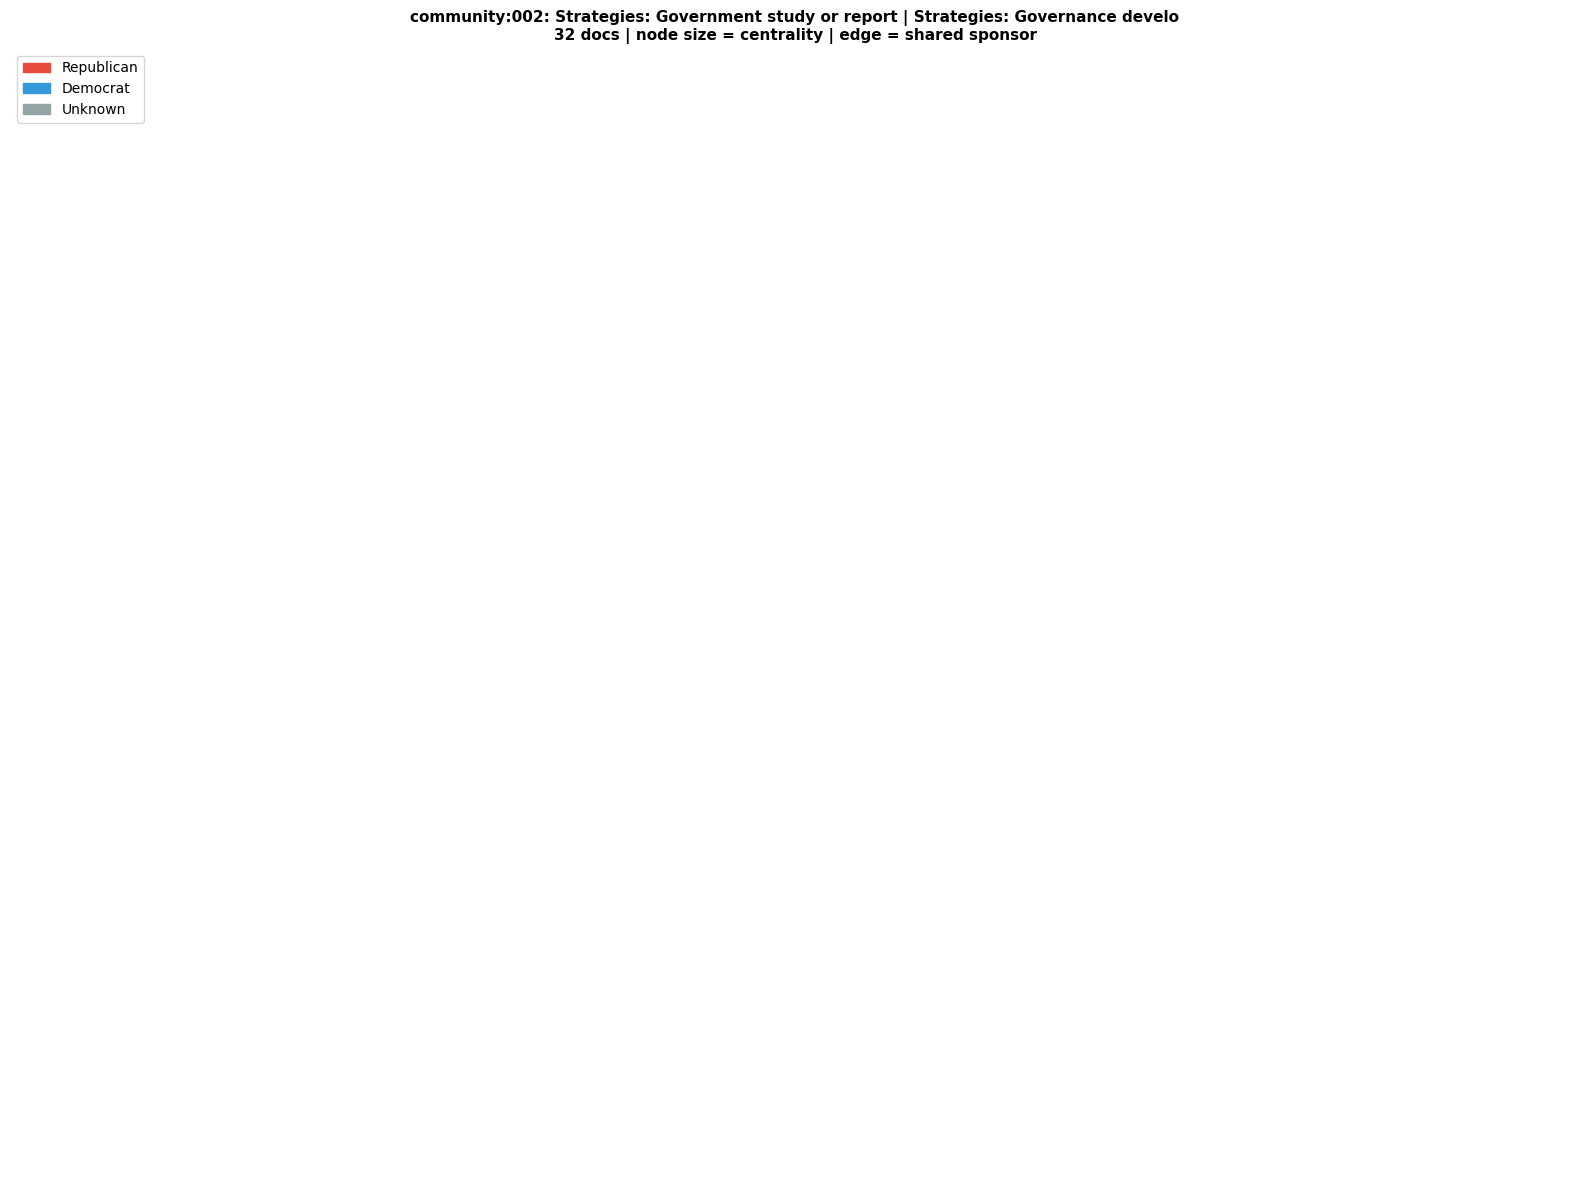

In [65]:
def plot_community(community_id: Union[str, int], figsize=(16, 12), k=3.0, seed=42):
    """Spring layout plot of a community's SHARES_SPONSOR subgraph."""
    if isinstance(community_id, int):
        community_id = f'community:{community_id:03d}'
    c = next((c for c in communities if c['community_id'] == community_id), None)
    if not c:
        print(f'Not found: {community_id}')
        return
    
    member_ids = set(c['member_agora_ids'])
    centrality = c.get('doc_centrality', {})
    
    # Subgraph
    sub = G_docs.subgraph(member_ids).copy()
    pos = nx.spring_layout(sub, k=k, iterations=120, seed=seed)
    
    fig, ax = plt.subplots(figsize=figsize)
    
    party_colors = {'R': '#e74c3c', 'D': '#3498db', '': '#95a5a6'}
    node_list = list(sub.nodes())
    node_colors = [party_colors.get(doc_meta.get(n, {}).get('party', ''), '#95a5a6') for n in node_list]
    node_sizes = [200 + centrality.get(n, 0) * 5000 for n in node_list]
    
    nx.draw_networkx_edges(sub, pos, alpha=0.2, edge_color='#aaa', width=0.8, ax=ax)
    nx.draw_networkx_nodes(sub, pos, nodelist=node_list, node_color=node_colors,
                           node_size=node_sizes, alpha=0.85, edgecolors='white', linewidths=0.8, ax=ax)
    
    labels = {}
    for n in node_list:
        name = doc_meta.get(n, {}).get('name', n)
        labels[n] = f"{n}\n{name[:28]}"
    nx.draw_networkx_labels(sub, pos, labels=labels, font_size=5, ax=ax)
    
    ax.legend(handles=[
        mpatches.Patch(color='#e74c3c', label='Republican'),
        mpatches.Patch(color='#3498db', label='Democrat'),
        mpatches.Patch(color='#95a5a6', label='Unknown'),
    ], loc='upper left', fontsize=10)
    ax.set_title(f'{community_id}: {c["label"][:70]}\n{len(member_ids)} docs | node size = centrality | edge = shared sponsor',
                 fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_community(2)

## 6. Experiment: Re-run Community Detection
Build the full pairwise similarity graph and run alternative algorithms.

In [66]:
import sys
sys.path.insert(0, str(ROOT))

from pipeline.agents.community_detector import (
    compute_pairwise_similarity,
    detect_communities
)

print('Imported community detector')

Imported community detector


In [67]:
# Load and prepare documents (same pipeline as community_detector.detect_communities)
from pipeline.agents.community_detector import build_bill_groups, compute_summary_tfidf, compute_taxonomy_jaccard, group_bills_by_url, load_docs_csv


all_rows = load_docs_csv(DATA_CSV)
url_to_ids = group_bills_by_url(all_rows)
bill_groups_raw = build_bill_groups(url_to_ids)

# Canonical rows: one representative per bill group (first member)
canonical_id_set = {grp[0] for grp in bill_groups_raw}
canonical_rows_exp = [r for r in all_rows if r['AGORA ID'].strip() in canonical_id_set]

# Get taxonomy columns from the data
taxonomy_cols = [k for k in all_rows[0].keys() if any(k.startswith(p) for p in ('Applications:', 'Harms:', 'Incentives:', 'Risk factors:', 'Strategies:'))]

# Precompute signals
tax_vectors = compute_taxonomy_jaccard(canonical_rows_exp, taxonomy_cols)
tfidf_vectors = compute_summary_tfidf(canonical_rows_exp)
canonical_ids = [r['AGORA ID'].strip() for r in canonical_rows_exp]

print(f'All docs: {len(all_rows)}  |  Canonical: {len(canonical_ids)}  |  Bill groups: {len(bill_groups_raw)}')

All docs: 535  |  Canonical: 32  |  Bill groups: 32


In [68]:
# Compute similarity (takes ~10-30s)
print('Computing pairwise similarity...')
edges = compute_pairwise_similarity(canonical_ids, tax_vectors, tfidf_vectors)
sim_matrix = {(a, b): s for a, b, s in edges}
print(f'Similarity matrix: {len(sim_matrix)} pairs')

# Score distribution
scores = list(sim_matrix.values())
print(f'p25={np.percentile(scores, 25):.3f}, p50={np.percentile(scores, 50):.3f}, '
      f'p75={np.percentile(scores, 75):.3f}, p90={np.percentile(scores, 90):.3f}')

Computing pairwise similarity...
Similarity matrix: 9 pairs
p25=0.262, p50=0.276, p75=0.286, p90=0.296


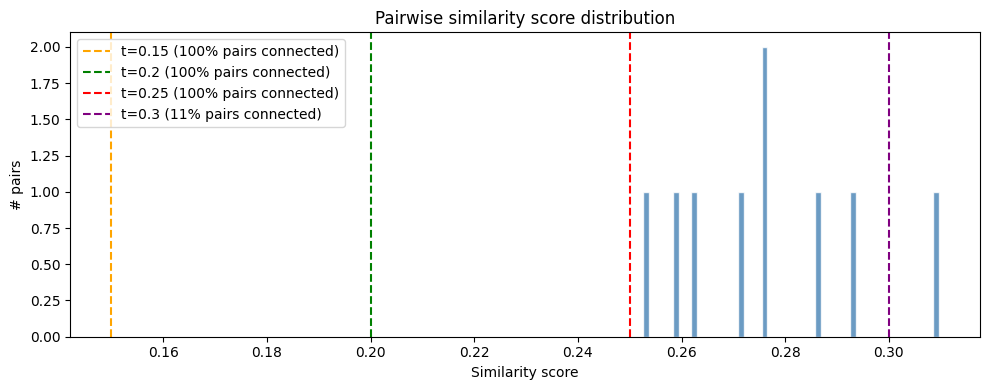

In [69]:
# Score distribution histogram
plt.figure(figsize=(10, 4))
plt.hist(scores, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
for thresh, color in [(0.15, 'orange'), (0.20, 'green'), (0.25, 'red'), (0.30, 'purple')]:
    frac = sum(1 for s in scores if s >= thresh) / len(scores)
    plt.axvline(thresh, color=color, linestyle='--', label=f't={thresh} ({frac:.0%} pairs connected)')
plt.xlabel('Similarity score')
plt.ylabel('# pairs')
plt.title('Pairwise similarity score distribution')
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
def run_louvain(threshold=0.25, resolution=1.5, seed=42):
    """Run Louvain on the canonical graph and print community sizes."""
    G = nx.Graph()
    G.add_nodes_from(canonical_ids)
    for (a, b), sim in sim_matrix.items():
        if sim >= threshold:
            G.add_edge(a, b, similarity=sim)
    
    comms_nx = nx.community.louvain_communities(G, resolution=resolution, seed=seed)
    sizes = sorted([len(c) for c in comms_nx], reverse=True)
    print(f'threshold={threshold}, resolution={resolution} → {len(comms_nx)} communities')
    print(f'Top-10 canonical sizes: {sizes[:10]}')
    print(f'Singletons: {sum(1 for s in sizes if s == 1)}')
    return comms_nx, G

# Default config
comms_default, G_sim = run_louvain(threshold=0.25, resolution=1.5)

threshold=0.25, resolution=1.5 → 24 communities
Top-10 canonical sizes: [4, 4, 3, 1, 1, 1, 1, 1, 1, 1]
Singletons: 21


In [ ]:
# Try different thresholds and resolutions
for thresh in [0.20, 0.25, 0.30]:
    for res in [1.0, 1.5, 2.0, 2.5]:
        c, _ = run_louvain(threshold=thresh, resolution=res)
        print()

In [74]:
# Alternative: Girvan-Newman (slow on large graphs — use only on subgraphs)
def run_girvan_newman(threshold=0.25, n_communities=10):
    G = nx.Graph()
    G.add_nodes_from(canonical_ids)
    for (a, b), sim in sim_matrix.items():
        if sim >= threshold:
            G.add_edge(a, b, similarity=sim)
    
    # Only run on the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    G_cc = G.subgraph(largest_cc).copy()
    print(f'Running Girvan-Newman on LCC: {G_cc.number_of_nodes()} nodes, {G_cc.number_of_edges()} edges')
    comp = nx.community.girvan_newman(G_cc)
    for _ in range(n_communities - 1):
        communities_gn = next(comp)
    sizes_gn = sorted([len(c) for c in communities_gn], reverse=True)
    print(f'Girvan-Newman ({n_communities} cuts) → sizes: {sizes_gn[:10]}')
    return communities_gn

# Uncomment to run (can be slow):
comms_gn = run_girvan_newman(threshold=0.25, n_communities=8)

Running Girvan-Newman on LCC: 4 nodes, 4 edges


StopIteration: 

In [75]:
# Label propagation (fast, non-deterministic)
def run_label_propagation(threshold=0.25, seed=42):
    G = nx.Graph()
    G.add_nodes_from(canonical_ids)
    for (a, b), sim in sim_matrix.items():
        if sim >= threshold:
            G.add_edge(a, b, similarity=sim)
    
    comms_lp = list(nx.community.label_propagation_communities(G))
    sizes = sorted([len(c) for c in comms_lp], reverse=True)
    print(f'Label propagation (t={threshold}) → {len(comms_lp)} communities')
    print(f'Top-10: {sizes[:10]}')
    return comms_lp

comms_lp = run_label_propagation(threshold=0.25)

Label propagation (t=0.25) → 24 communities
Top-10: [4, 4, 3, 1, 1, 1, 1, 1, 1, 1]


In [76]:
# Greedy modularity (fast, deterministic)
def run_greedy_modularity(threshold=0.25):
    G = nx.Graph()
    G.add_nodes_from(canonical_ids)
    for (a, b), sim in sim_matrix.items():
        if sim >= threshold:
            G.add_edge(a, b, similarity=sim)
    
    comms_gm = list(nx.community.greedy_modularity_communities(G))
    sizes = sorted([len(c) for c in comms_gm], reverse=True)
    print(f'Greedy modularity (t={threshold}) → {len(comms_gm)} communities')
    print(f'Top-10: {sizes[:10]}')
    return comms_gm

comms_gm = run_greedy_modularity(threshold=0.25)

Greedy modularity (t=0.25) → 24 communities
Top-10: [4, 4, 3, 1, 1, 1, 1, 1, 1, 1]


In [77]:
from collections import Counter

def score_partition(comms_nx, G):
    """Score a community partition across multiple objectives."""
    sizes = sorted([len(c) for c in comms_nx], reverse=True)
    n = sum(sizes)
    Q = nx.community.modularity(G, comms_nx, weight='similarity')
    singleton_rate = sum(1 for s in sizes if s == 1) / len(sizes)
    largest_frac = sizes[0] / n if sizes else 0
    purities = []
    for c in comms_nx:
        if len(c) <= 1:
            continue
        parties = [doc_meta.get(a, {}).get('party', '') for a in c]
        counts = Counter(parties)
        purities.append(max(counts.values()) / len(parties))
    party_purity = float(np.mean(purities)) if purities else 0.0
    coverage = sum(s for s in sizes if s > 1) / n
    return dict(modularity=round(Q, 4), singleton_rate=round(singleton_rate, 3),
                largest_frac=round(largest_frac, 3), party_purity=round(party_purity, 3),
                coverage=round(coverage, 3), n_communities=len(comms_nx))

In [80]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    thresh    = trial.suggest_float('threshold',   0.10, 0.50)
    res       = trial.suggest_float('resolution',  0.5,  5.0)
    w_tax     = trial.suggest_float('w_tax',       0.30, 0.80)
    w_cos     = trial.suggest_float('w_cos',       0.05, 0.40)
    if w_tax + w_cos > 0.95:
        raise optuna.TrialPruned()
    w_dense   = 1.0 - w_tax - w_cos - 0.05  # cosponsor fixed at 0.05
    if w_dense < 0.0:
        raise optuna.TrialPruned()

    weights = {'jaccard_taxonomy': w_tax, 'cosine_summary': w_cos,
               'dense_cosine': w_dense, 'cosponsor_jaccard': 0.05}

    # Recompute edges with these weights
    trial_edges = compute_pairwise_similarity(
        canonical_ids, tax_vectors, tfidf_vectors, dense_vectors, weights=weights
    )
    trial_sim = {(a, b): s for a, b, s in trial_edges}

    G = nx.Graph()
    G.add_nodes_from(canonical_ids)
    for (a, b), sim in trial_sim.items():
        if sim >= thresh:
            G.add_edge(a, b, similarity=sim)

    comms = nx.community.louvain_communities(G, resolution=res, seed=42)
    m = score_partition(comms, G)

    # Four objectives: maximize modularity, minimize singleton_rate,
    # minimize largest_frac, maximize party_purity
    return m['modularity'], m['singleton_rate'], m['largest_frac'], -m['party_purity']

study = optuna.create_study(
    directions=['maximize', 'minimize', 'minimize', 'minimize'],
    sampler=optuna.samplers.NSGAIISampler(seed=42)
)
study.optimize(objective, n_trials=300, show_progress_bar=True)

print(f'Pareto front: {len(study.best_trials)} non-dominated solutions')

/Users/vthakur/Documents/auto/agora/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  0%|          | 0/300 [00:00<?, ?it/s]

[W 2026-03-12 17:02:15,155] Trial 0 failed with parameters: {'threshold': 0.249816047538945, 'resolution': 4.7782143788446225, 'w_tax': 0.6659969709057025, 'w_cos': 0.25953046946896285} because of the following error: NameError("name 'dense_vectors' is not defined").
Traceback (most recent call last):
  File "/Users/vthakur/Documents/auto/agora/.venv/lib/python3.9/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/hn/h8rpgfk93hj23z8n4nc8vhgh0000gn/T/ipykernel_10351/329482608.py", line 20, in objective
    canonical_ids, tax_vectors, tfidf_vectors, dense_vectors, weights=weights
NameError: name 'dense_vectors' is not defined
[W 2026-03-12 17:02:15,160] Trial 0 failed with value None.


NameError: name 'dense_vectors' is not defined

In [79]:
!pip install optuna

     |████████████████████████████████| 413 kB 2.6 MB/s eta 0:00:01
     |████████████████████████████████| 2.2 MB 46.4 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 27.5 MB/s eta 0:00:01
     |████████████████████████████████| 174 kB 20.2 MB/s eta 0:00:01
     |████████████████████████████████| 247 kB 21.9 MB/s eta 0:00:01
     |████████████████████████████████| 78 kB 35.6 MB/s eta 0:00:01
  Using cached markupsafe-3.0.3-cp39-cp39-macosx_11_0_arm64.whl (12 kB)
You should consider upgrading via the '/Users/vthakur/Documents/auto/agora/.venv/bin/python3 -m pip install --upgrade pip' command.


In [81]:
pareto = study.best_trials
df_pareto = pd.DataFrame([
    {**t.params, **dict(zip(
        ['modularity','singleton_rate','largest_frac','neg_purity'], t.values
    ))}
    for t in pareto
])
df_pareto['party_purity'] = -df_pareto['neg_purity']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].scatter(df_pareto['threshold'], df_pareto['resolution'],
                c=df_pareto['modularity'], cmap='RdYlGn', s=60)
axes[0].set_xlabel('threshold'); axes[0].set_ylabel('resolution')
axes[0].set_title('Pareto: threshold vs resolution (color=modularity)')

axes[1].scatter(df_pareto['singleton_rate'], df_pareto['largest_frac'],
                c=df_pareto['modularity'], cmap='RdYlGn', s=60)
axes[1].set_xlabel('singleton rate'); axes[1].set_ylabel('largest frac')
axes[1].set_title('Pareto: singleton rate vs largest community')

axes[2].scatter(df_pareto['modularity'], df_pareto['party_purity'], s=60, color='steelblue')
axes[2].set_xlabel('modularity'); axes[2].set_ylabel('party purity')
axes[2].set_title('Pareto: modularity vs party purity')
plt.tight_layout(); plt.show()

# Print top 5 by modularity that also pass hard filters
good = df_pareto[
    (df_pareto['largest_frac'] < 0.15) &
    (df_pareto['singleton_rate'] < 0.30)
].sort_values('modularity', ascending=False).head(5)
print(good[['threshold','resolution','w_tax','w_cos','modularity','singleton_rate','largest_frac','party_purity']].to_string())

NameError: name 'pd' is not defined

In [ ]:
if len(good) > 0:
    best = good.iloc[0]
    print(f'Update pipeline/config.py:')
    print(f'  SIMILARITY_THRESHOLD = {best.threshold:.3f}')
    print(f'  LOUVAIN_RESOLUTION   = {best.resolution:.2f}')
    print(f'  COMMUNITY_SIMILARITY_WEIGHTS = {{')
    print(f'      \'jaccard_taxonomy\':  {best.w_tax:.3f},')
    print(f'      \'cosine_summary\':    {best.w_cos:.3f},')
    print(f'      \'dense_cosine\':      {1.0 - best.w_tax - best.w_cos - 0.05:.3f},')
    print(f'      \'cosponsor_jaccard\': 0.05,')
    print(f'  }}')
else:
    print('No solutions found that pass hard filters (largest < 15%, singleton < 30%)')

## 7. Sub-cluster a Single Large Community
Zoom into one community and split it further.

In [ ]:
def subcluster_community(community_id: Union[str, int], resolution=2.5, threshold=0.25, seed=42):
    """Re-run Louvain on just one community's subgraph at higher resolution."""
    if isinstance(community_id, int):
        community_id = f'community:{community_id:03d}'
    c = next((c for c in communities if c['community_id'] == community_id), None)
    if not c:
        print(f'Not found: {community_id}')
        return
    
    # Get canonical IDs in this community
    canonical_in_community = [cid for cid in canonical_ids if cid in c['member_agora_ids']]
    
    # Build subgraph with edges within community
    G_sub = nx.Graph()
    G_sub.add_nodes_from(canonical_in_community)
    for (a, b), sim in sim_matrix.items():
        if a in canonical_in_community and b in canonical_in_community and sim >= threshold:
            G_sub.add_edge(a, b, similarity=sim)
    
    print(f'{community_id}: {len(canonical_in_community)} canonical nodes, {G_sub.number_of_edges()} edges')
    
    if G_sub.number_of_edges() == 0:
        print('No internal edges — cannot sub-cluster')
        return
    
    sub_comms = nx.community.louvain_communities(G_sub, resolution=resolution, seed=seed)
    sizes = sorted([len(sc) for sc in sub_comms], reverse=True)
    print(f'resolution={resolution} → {len(sub_comms)} sub-communities, sizes: {sizes}')
    
    for i, sc in enumerate(sorted(sub_comms, key=lambda x: -len(x))[:5]):
        for aid in list(sc)[:1]:
            meta = doc_meta.get(aid, {})
            print(f'  Sub {i+1} ({len(sc)} docs): {meta.get("name", aid)[:60]}')
            break
    return sub_comms

# Sub-cluster the military community
_ = subcluster_community(1, resolution=2.5)

In [ ]:
# Try different resolutions on community 1
for res in [2.0, 2.5, 3.0, 4.0, 5.0]:
    subcluster_community(1, resolution=res)

## 8. Visualize Similarity Graph Structure

/var/folders/hn/h8rpgfk93hj23z8n4nc8vhgh0000gn/T/ipykernel_10351/3717629543.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', min(20, len(communities)))


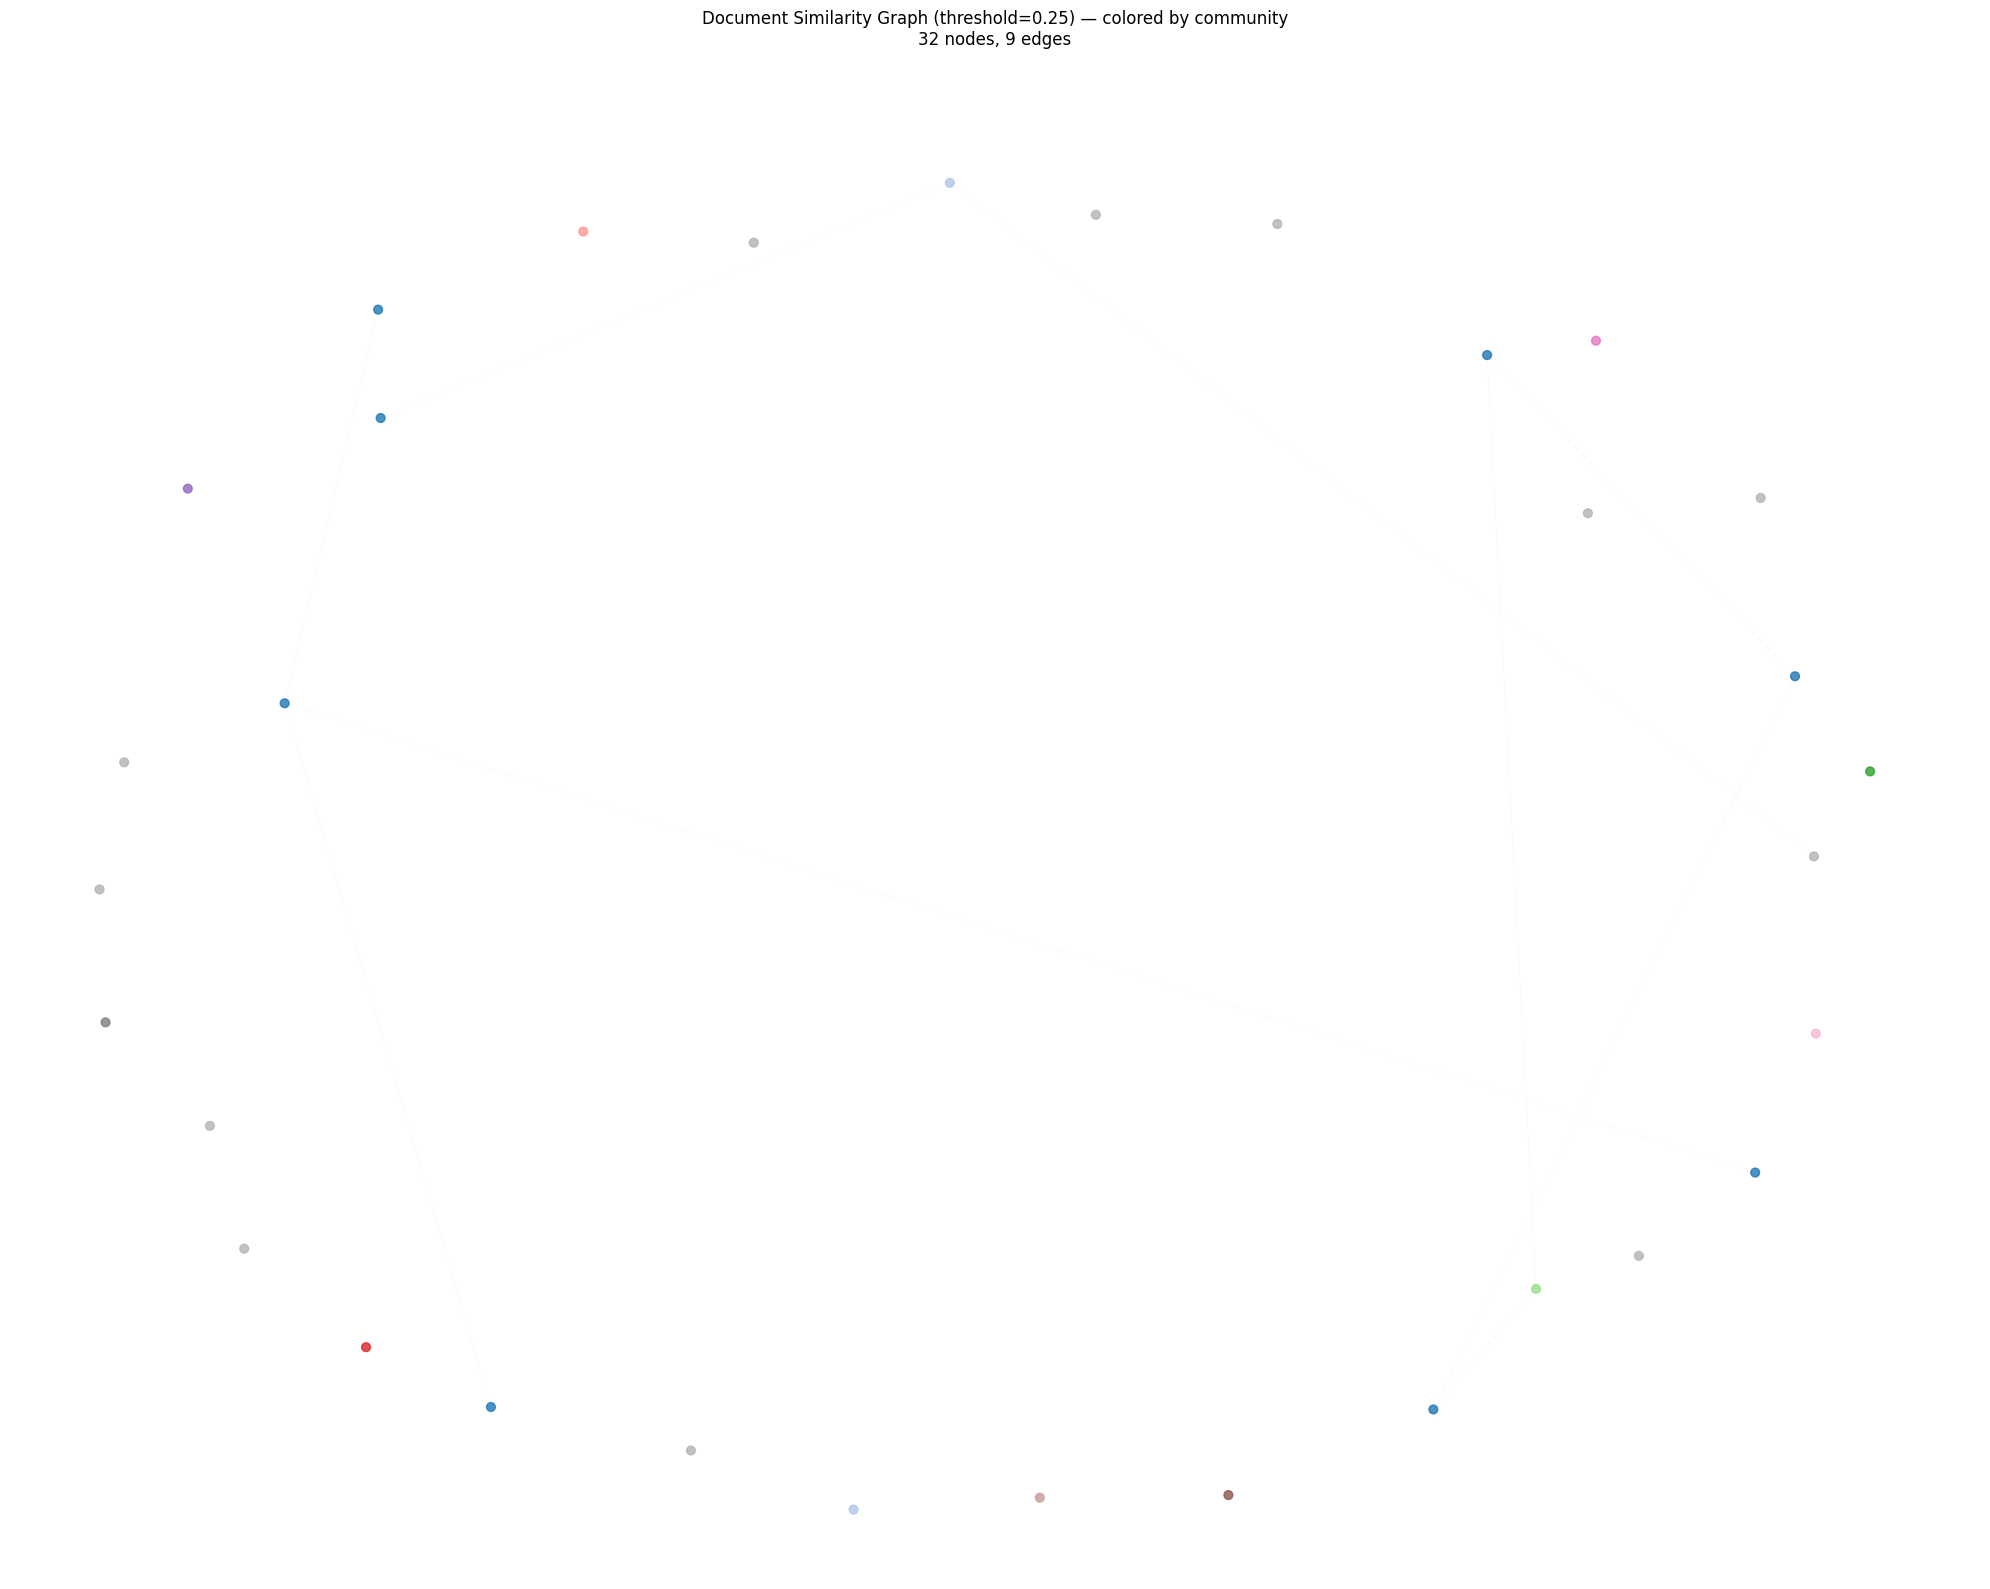

In [82]:
def plot_similarity_graph(threshold=0.25, layout='spring', figsize=(20, 16), seed=42):
    """Plot full document similarity graph colored by community."""
    G = nx.Graph()
    G.add_nodes_from(canonical_ids)
    for (a, b), sim in sim_matrix.items():
        if sim >= threshold:
            G.add_edge(a, b, similarity=sim)
    
    # Color by current community assignment
    community_colors = {}
    cmap = plt.cm.get_cmap('tab20', min(20, len(communities)))
    for i, c in enumerate(sorted(communities, key=lambda x: -len(x['member_agora_ids']))[:20]):
        for aid in c['member_agora_ids']:
            community_colors[aid] = cmap(i)
    
    node_list = list(G.nodes())
    node_colors = [community_colors.get(n, (0.7, 0.7, 0.7, 0.5)) for n in node_list]
    
    fig, ax = plt.subplots(figsize=figsize)
    if layout == 'spring':
        pos = nx.spring_layout(G, k=2.5, seed=seed, iterations=80)
    else:
        pos = nx.kamada_kawai_layout(G)
    
    nx.draw_networkx_edges(G, pos, alpha=0.08, edge_color='#999', width=0.4, ax=ax)
    nx.draw_networkx_nodes(G, pos, nodelist=node_list, node_color=node_colors,
                           node_size=40, alpha=0.8, ax=ax)
    
    ax.set_title(f'Document Similarity Graph (threshold={threshold}) — colored by community\n'
                 f'{G.number_of_nodes()} nodes, {G.number_of_edges()} edges', fontsize=12)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

plot_similarity_graph(threshold=0.25)


## 9. Export Best Configuration
Once you find a good parameter set, re-run the full pipeline to persist the communities.json.

In [ ]:
# To persist a new community configuration:
# Update pipeline/config.py, then run:
# !cd .. && python -m pipeline.cli detect-communities \
#   --sponsors-csv knowledge_graph/data/agora_with_sponsors.csv \
#   --inspect

# Current config:
import importlib
import pipeline.config as cfg
importlib.reload(cfg)
print(f'SIMILARITY_THRESHOLD = {cfg.SIMILARITY_THRESHOLD}')
print(f'LOUVAIN_RESOLUTION = {cfg.LOUVAIN_RESOLUTION}')
print(f'SUBCLUSTERING_SIZE_THRESHOLD = {cfg.SUBCLUSTERING_SIZE_THRESHOLD}')
print(f'SUBCLUSTERING_RESOLUTION = {cfg.SUBCLUSTERING_RESOLUTION}')